In [9]:
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [10]:
orders_shipped = pd.read_csv("data/order_shipped_dates.csv", parse_dates=['event_timestamp'])

In [11]:
orders_shipped.head()

,ed_id,event_timestamp
0,28,2021-06-23 00:00:00+00:00
1,28,2021-04-08 00:00:00+00:00
2,28,2021-08-18 00:00:00+00:00
3,28,2021-04-05 00:00:00+00:00
4,28,2022-06-07 00:00:00+00:00


In [12]:
daily_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('D')
        .size()
)

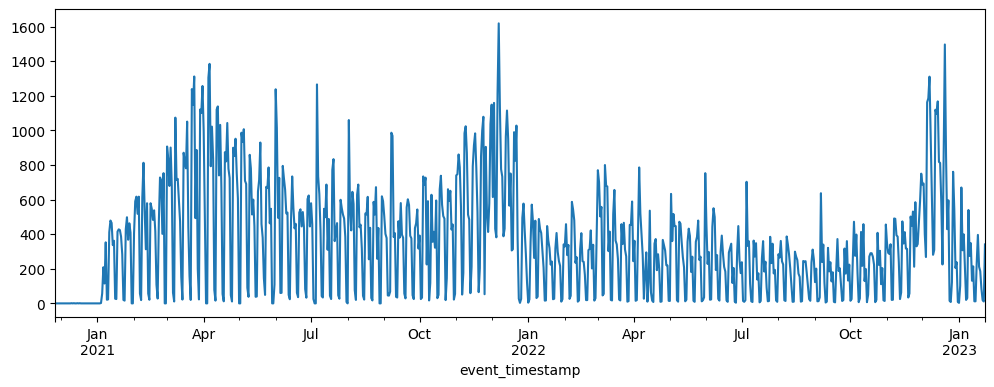

In [13]:
daily_orders.plot(figsize=(12, 4))
plt.show()

In [14]:
# Top 10 days with most orders shipped, clear holiday for Christmas/winter holiday peak
daily_orders.sort_values(ascending=False)[:10]

event_timestamp
2021-12-07 00:00:00+00:00    1619
2022-12-20 00:00:00+00:00    1497
2021-04-06 00:00:00+00:00    1385
2021-03-24 00:00:00+00:00    1312
2022-12-07 00:00:00+00:00    1311
2021-04-05 00:00:00+00:00    1305
2021-07-06 00:00:00+00:00    1266
2021-03-31 00:00:00+00:00    1257
2021-03-22 00:00:00+00:00    1239
2021-06-01 00:00:00+00:00    1238
dtype: int64

In [15]:
bimonthly_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('SMS')
        .size()
)

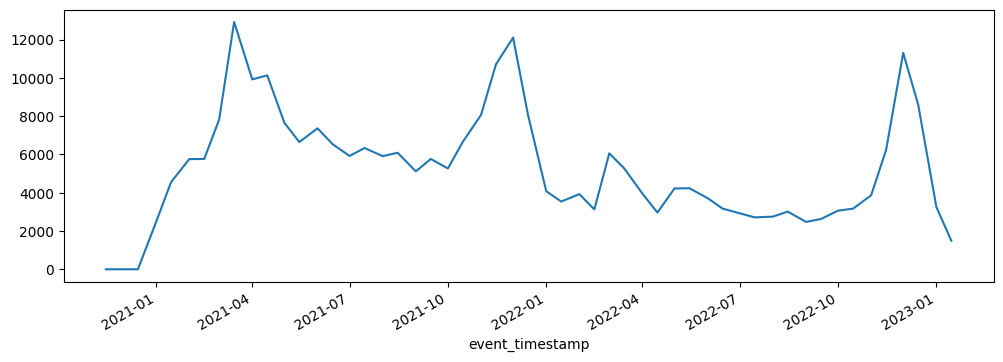

In [16]:
bimonthly_orders.plot(figsize=(12, 4))
plt.show()

In [17]:
monthly_orders = (
    orders_shipped
        .set_index('event_timestamp')
        .resample('MS')
        .size()
)

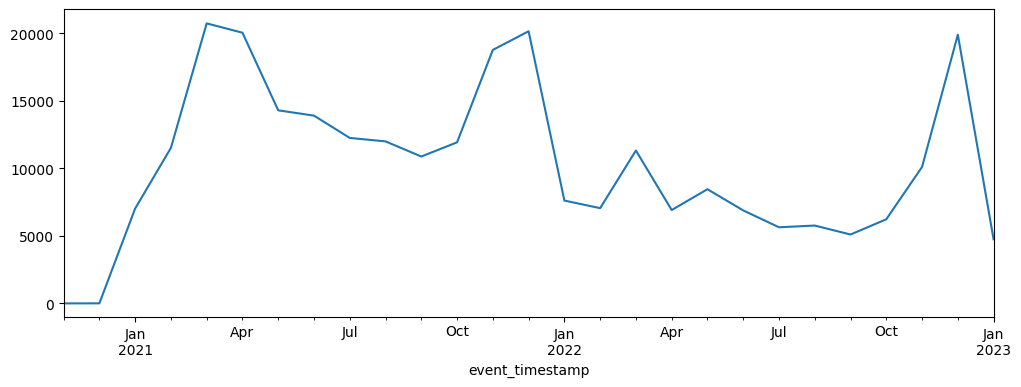

In [18]:
monthly_orders.plot(figsize=(12, 4))
plt.show()

Our actual model will be fit to either monthly or bi-monthly data, which we will ultimately use to project the ordered quantity for each month.

### Monthly Data Model

In [19]:
df_monthly = monthly_orders.reset_index().rename(columns={'event_timestamp': 'ds', 0: 'y'})
df_monthly = df_monthly.loc[df_monthly['ds'] >= '2021-01-01'].reset_index(drop=True)
df_monthly['ds'] = df_monthly['ds'].dt.date

# Add upper and lower limits
df_monthly['cap'] = int(1.1 * df_monthly['y'].max())
df_monthly['floor'] = 4000

holidays = pd.DataFrame({
    'holiday': 'winter_holiday',
    'ds': pd.to_datetime(['2021-12-01', '2022-12-01', '2023-12-01', '2024-12-01'])
})

In [20]:
model = Prophet(growth='logistic', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, holidays=holidays)
model.add_seasonality(
    name='annual',
    period=365.25,
    fourier_order=3,
    prior_scale=1.0
)
model.fit(df_monthly)

future_dates = model.make_future_dataframe(periods=24, freq='MS')
future_dates['cap'] = df_monthly.loc[0, 'cap']
future_dates['floor'] = df_monthly.loc[0, 'floor']
forecast_df = model.predict(future_dates)

11:55:19 - cmdstanpy - INFO - Chain [1] start processing
11:55:20 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
44,2024-09-01,1805.083369,-997.833687,4578.702634
45,2024-10-01,5526.280157,2826.150641,8255.703406
46,2024-11-01,9056.301781,6414.673308,11594.625317
47,2024-12-01,15695.044880,13185.731291,18537.442977
48,2025-01-01,-91.389144,-2715.671982,2756.505492


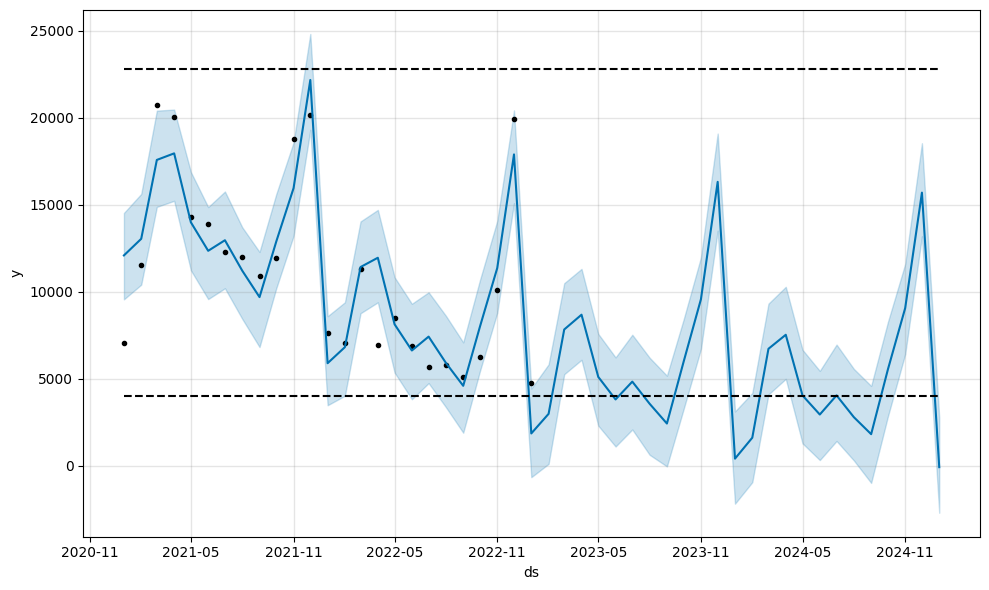

In [22]:
model.plot(forecast_df)
plt.show()

In [23]:
print(f"Number of negative month predictions: {forecast_df[forecast_df['yhat'] < 0].shape[0]}")

Number of negative month predictions: 1


In [24]:
forecast_df.loc[forecast_df['yhat'] < 0, 'yhat']

48   -91.389144
Name: yhat, dtype: float64

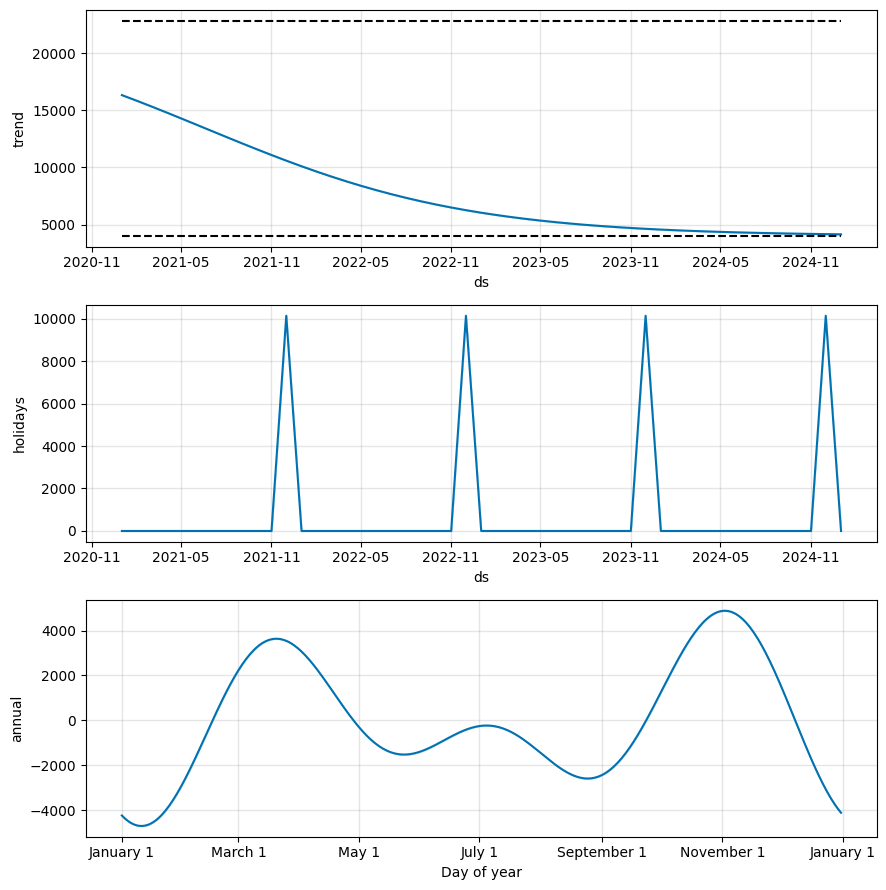

In [25]:
model.plot_components(forecast_df)
plt.show()

Holidays removed

In [26]:
df_monthly = monthly_orders.reset_index().rename(columns={'event_timestamp': 'ds', 0: 'y'})
df_monthly = df_monthly.loc[df_monthly['ds'] >= '2021-01-01'].reset_index(drop=True)
df_monthly['ds'] = df_monthly['ds'].dt.date

# Add upper and lower limits
df_monthly['cap'] = int(1.1 * df_monthly['y'].max())
df_monthly['floor'] = 4000

In [27]:
model = Prophet(growth='logistic', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
model.add_seasonality(
    name='annual',
    period=365.25,
    fourier_order=3,
    prior_scale=1.0
)
model.fit(df_monthly)

future_dates = model.make_future_dataframe(periods=24, freq='MS')
future_dates['cap'] = df_monthly.loc[0, 'cap']
future_dates['floor'] = df_monthly.loc[0, 'floor']
forecast_df = model.predict(future_dates)

11:55:28 - cmdstanpy - INFO - Chain [1] start processing
11:55:28 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(n=13)

,ds,yhat,yhat_lower,yhat_upper
36,2024-01-01,2499.167130,-1039.807275,6140.615955
37,2024-02-01,67.588255,-3578.272311,3689.657817
38,2024-03-01,5548.750566,1979.696236,9075.125212
39,2024-04-01,7958.453057,4233.809967,11444.944051
40,2024-05-01,3642.828140,177.463356,7501.321418
41,2024-06-01,1503.674341,-2169.768132,5352.447957
42,2024-07-01,3744.193492,130.114997,7644.911890
43,2024-08-01,2983.021249,-638.216067,6618.569728
44,2024-09-01,209.216470,-3475.557700,3994.129135
45,2024-10-01,4140.183955,644.437776,8103.771508


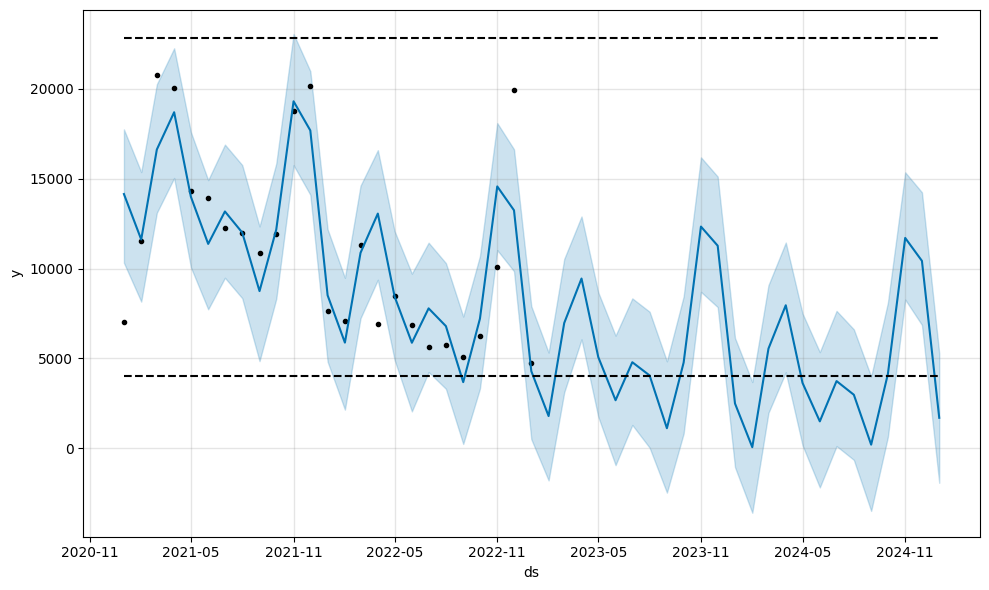

In [29]:
model.plot(forecast_df)
plt.show()

In [30]:
print(f"Number of negative month predictions: {forecast_df[forecast_df['yhat'] < 0].shape[0]}")

Number of negative month predictions: 0


In [31]:
forecast_df.loc[forecast_df['yhat'] < 0, 'yhat']

Series([], Name: yhat, dtype: float64)

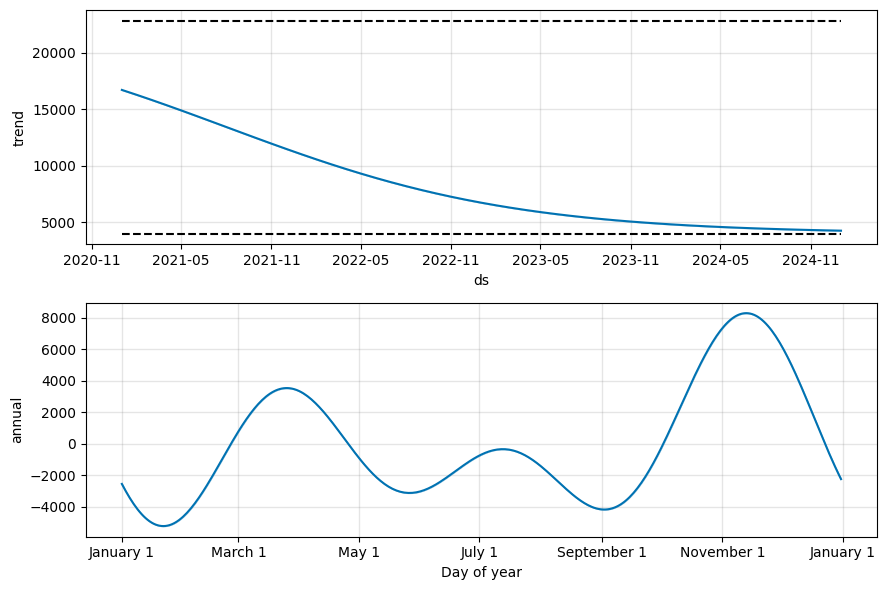

In [32]:
model.plot_components(forecast_df)
plt.show()

In [38]:
model.params.keys()

odict_keys(['lp__', 'k', 'm', 'delta', 'sigma_obs', 'beta', 'trend'])

In [ ]:
print(f"Growth rate: {model.params['k'][0][0]}")
print(f"Offset: {model.params['m'][0][0]}")
print(f"Trend: {model.params['trend']}")
print(f"Growth rate changepoints: {model.params['delta']}")

Growth rate: -2.5032344
Offset: 0.29142368
Trend: [[0.75825734 0.73156597 0.70670691 0.6784626  0.65052903 0.6211865
  0.59247416 0.5626375  0.53279682 0.50407303 0.4747111  0.44675184
  0.41847439 0.39095334 0.36684487 0.34107742 0.31714354 0.29351356
  0.27175856 0.25046027 0.23037988 0.21210895 0.19441888 0.17843038
  0.16304683]]
Growth rate changepoints: [[-9.4121843e-11  7.5117450e-11  8.4649106e-11 -4.0133471e-11
   6.0683630e-11 -6.9091700e-12 -3.7915037e-11 -2.6878659e-11
  -7.8416676e-11 -9.0805315e-11 -7.4540627e-11 -7.6395511e-11
  -2.9098900e-11 -6.4359234e-11 -5.5997736e-11 -8.5111513e-11
  -9.2615532e-11 -6.8623823e-11  8.7658466e-11]]
